<a href="https://colab.research.google.com/github/samuelperez1232/prospectiva_analitica_datos/blob/main/taller2_caso_coordinadora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EJERCICIO PRÁCTICO (ENTREGABLE 1)

## CASO DE ESTUDIO
CASO DE ESTUDIO

COORDINADORA MERCANTIL S.A. es una empresa colombiana líder en logística y distribución, con más de 40 años de operación en el país. Su unidad de e-commerce, Coordinadora Fulfillment, gestiona actualmente más de 120 centros de distribución a lo largo del territorio nacional, procesando en promedio 2.8 millones de pedidos mensuales para más de 15.000 comercios digitales activos.

La empresa está interesada en desarrollar un sistema por adaptación y aprendizaje que le permita proyectar, desde la gestión de sus riesgos operacionales, el valor potencial de pérdidas asociadas a fallas en la cadena de entrega de última milla en el área metropolitana del Valle de Aburrá.

Las barreras que serán utilizadas para este proceso son las siguientes:

- Frecuencia: indica el número de pedidos no entregados a tiempo por mes en los centros de distribución monitoreados (número de eventos/mes).

- Severidad: es el costo promedio de gestión por cada incidente operacional, incluyendo reenvíos, penalizaciones contractuales y pérdida de mercancía (COP Miles/evento).

- Distribución de Pérdidas: es el producto entre la frecuencia y la severidad. Esta distribución agrega los parámetros de riesgo y permite estimar el capital en riesgo operacional (OpVaR) bajo el enfoque de Distribución Agregada de Pérdidas (LDA).

###0. las librerias ya fueron importadas


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###1.creamos el data frame

A continuación, se describen los títulos de las columnas en el DataFrame:

*   **Pedidos_Procesados_Mes**: Representa la cantidad total de pedidos que fueron procesados en un mes específico, simulando la carga de trabajo o volumen de operaciones.
*   **Valor_Operado_COP_Miles**: Indica el valor monetario total, en miles de COP (pesos colombianos), de las operaciones o mercancías gestionadas durante un mes.
*   **Frecuencia**: Es el número de eventos o incidentes (pedidos no entregados a tiempo) ocurridos en un mes.
*   **Severidad_COP_Miles**: Mide el costo promedio, en miles de COP, asociado a cada incidente operacional, como reenvíos o penalizaciones.
*   **Distribucion_Perdidas_COP_Miles**: Es el resultado de multiplicar la Frecuencia por la Severidad, representando la pérdida total estimada en miles de COP debido a incidentes operacionales.
*   **Tipo_Evento**: Categoriza la naturaleza del incidente ocurrido, como 'Entrega Fallida', 'Daño en Mercancía', etc.
*   **Nivel_Impacto**: Un valor numérico (1 a 5) que clasifica la magnitud del impacto de un incidente, correlacionado positivamente con la Severidad.
*   **Nivel_Gestion**: Describe el tipo de estrategia o acción de gestión requerida para el incidente, en función de su Nivel de Impacto.
*   **Costo_Por_Pedido_USD**: El costo promedio, en USD, asociado a cada pedido, el cual aumenta progresivamente según el Nivel de Impacto del incidente.

In [3]:
import numpy as np
import pandas as pd

# Establecer una semilla para reproducibilidad
np.random.seed(42)

N = 1000 # Número de registros

# 2. Pedidos_Procesados_Mes (500 a 5,000)
CDB = pd.DataFrame({'Pedidos_Procesados_Mes': np.random.randint(500, 5001, N)})

# 3. Valor_Operado_USD (12,500 a 200,000 USD)
# Los rangos originales de 50,000 a 800,000 COP_Miles se convierten a USD.
CDB['Valor_Operado_USD'] = np.random.uniform(12500, 200000, N)

# 4. Frecuencia (2 a 80, asimetría positiva > 1.0 con Poisson)
# Usar un lambda bajo para asegurar asimetría positiva en la distribución de Poisson
# Los valores generados se recortarán para ajustarse al rango [2, 80]
lambda_freq_param = 8 # Un valor lambda entre 5 y 15 suele dar buena asimetría para este rango
frecuencia_raw = np.random.poisson(lambda_freq_param, N)
CDB['Frecuencia'] = np.clip(frecuencia_raw, 2, 80)

# 5. Severidad_USD (12.5 a 500 USD)
# Ajustar mean_log y sigma_log para obtener asimetría positiva y valores en el rango deseado en USD
# Un valor mediano de ~80 USD y una dispersión adecuada.
mean_log_usd = 4.38 # log(80) ~ 4.38, donde 80 es la mediana esperada en USD
sigma_log_usd = 0.9  # Ajustar para la dispersión y asimetría deseada

severidad_raw_usd = np.random.lognormal(mean_log_usd, sigma_log_usd, N)
CDB['Severidad_USD'] = np.clip(severidad_raw_usd, 12.5, 500)

# 6. Distribucion_Perdidas_USD (Frecuencia * Severidad_USD)
CDB['Distribucion_Perdidas_USD'] = CDB['Frecuencia'] * CDB['Severidad_USD']

# 7. Tipo_Evento
tipo_eventos = ['Entrega Fallida', 'Daño en Mercancía', 'Error de Inventario', 'Falla de Sistema', 'Incidente Laboral']
CDB['Tipo_Evento'] = np.random.choice(tipo_eventos, N, p=[0.3, 0.25, 0.2, 0.15, 0.1]) # Distribución de probabilidad ajustada

# 8. Nivel_Impacto (1 a 5, correlacionado positivamente con Severidad_USD)
# Primero, ordenamos el DataFrame por severidad para asignar el impacto de forma correlacionada
CDB_sorted = CDB.sort_values(by='Severidad_USD').reset_index(drop=True)

# Asignamos Nivel_Impacto en función de los quintiles de Severidad para lograr la correlación
def assign_impact_level(severity_series):
    impact_levels = np.zeros(len(severity_series), dtype=int)
    p20 = severity_series.quantile(0.2)
    p40 = severity_series.quantile(0.4)
    p60 = severity_series.quantile(0.6)
    p80 = severity_series.quantile(0.8)

    impact_levels[severity_series <= p20] = 1
    impact_levels[(severity_series > p20) & (severity_series <= p40)] = 2
    impact_levels[(severity_series > p40) & (severity_series <= p60)] = 3
    impact_levels[(severity_series > p60) & (severity_series <= p80)] = 4
    impact_levels[severity_series > p80] = 5
    return impact_levels

CDB_sorted['Nivel_Impacto'] = assign_impact_level(CDB_sorted['Severidad_USD'])

# Mezclar el DataFrame para que el orden no esté ligado a la severidad
CDB = CDB_sorted.sample(frac=1, random_state=42).reset_index(drop=True)

# 9. Nivel_Gestion (derivado de Nivel_Impacto)
nivel_gestion_map = {
    1: 'Control Básico de Rutina',
    2: 'Control Periódico Preventivo',
    3: 'Monitoreo Regular y Correctivos',
    4: 'Control Rigurosamente Planificado',
    5: 'Intervención Crítica Inmediata'
}
CDB['Nivel_Gestion'] = CDB['Nivel_Impacto'].map(nivel_gestion_map)

# 10. Costo_Por_Pedido_USD (aumenta progresivamente con Nivel_Impacto)
# Definir los rangos de costo para cada Nivel_Impacto en USD
costo_por_impacto = {
    1: lambda: np.random.uniform(0.05, 0.20),
    2: lambda: np.random.uniform(0.20, 0.50),
    3: lambda: np.random.uniform(0.50, 0.90),
    4: lambda: np.random.uniform(0.90, 1.20),
    5: lambda: np.random.uniform(1.20, 1.50)
}

# Aplicar la función lambda para generar un costo por pedido en USD
CDB['Costo_Por_Pedido_USD'] = CDB['Nivel_Impacto'].apply(lambda x: costo_por_impacto[x]())

print("DataFrame generado:")
display(CDB.head())
print("\nEstadísticas descriptivas del DataFrame:")
display(CDB.describe())

print("\nSkewness de Frecuencia:", CDB['Frecuencia'].skew())
print("Skewness de Severidad_USD:", CDB['Severidad_USD'].skew())
print("Skewness de Distribucion_Perdidas_USD:", CDB['Distribucion_Perdidas_USD'].skew())

DataFrame generado:


,Pedidos_Procesados_Mes,Valor_Operado_USD,Frecuencia,Severidad_USD,Distribucion_Perdidas_USD,Tipo_Evento,Nivel_Impacto,Nivel_Gestion,Costo_Por_Pedido_USD
0,1173,110231.399841,8,85.730651,685.845207,Daño en Mercancía,3,Monitoreo Regular y Correctivos,0.839103
1,1752,138143.006490,9,140.658885,1265.929966,Error de Inventario,4,Control Rigurosamente Planificado,1.012992
2,4952,167096.383793,7,141.144682,988.012776,Error de Inventario,4,Control Rigurosamente Planificado,1.072174
3,4929,56103.379694,6,117.157168,702.943008,Entrega Fallida,4,Control Rigurosamente Planificado,0.908152
4,2145,159470.501894,4,64.458560,257.834240,Falla de Sistema,3,Monitoreo Regular y Correctivos,0.605289



Estadísticas descriptivas del DataFrame:


,Pedidos_Procesados_Mes,Valor_Operado_USD,Frecuencia,Severidad_USD,Distribucion_Perdidas_USD,Nivel_Impacto,Costo_Por_Pedido_USD
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2815.422000,105887.375298,7.925000,111.853189,888.358536,3.000000,0.712948
std,1255.514921,53634.698783,2.893397,99.719508,863.204185,1.414921,0.453820
min,503.000000,12544.535670,2.000000,12.500000,25.000000,1.000000,0.050169
25%,1749.500000,58844.821513,6.000000,42.911493,287.025592,2.000000,0.274709
50%,2862.500000,108329.553372,8.000000,80.341347,588.473000,3.000000,0.681755
75%,3849.500000,151932.051117,10.000000,146.945217,1198.815313,4.000000,1.109592
max,4999.000000,199878.781169,18.000000,500.000000,6000.000000,5.000000,1.495946



Skewness de Frecuencia: 0.2502335098084531
Skewness de Severidad_USD: 1.799325335627482
Skewness de Distribucion_Perdidas_USD: 2.040766065283536


###2. realizamos el histograma

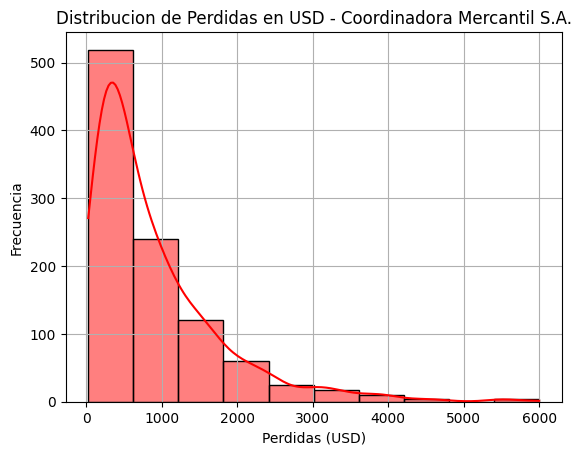

In [4]:
Freq = CDB.iloc[:,2] # Extrae la columna 'Frecuencia' del DataFrame 'CDB'
Sev = CDB.iloc[:,3] # Extrae la columna 'Severidad_USD' del DataFrame 'CDB'
LDA_Coordinadora = Freq * Sev # Calcula la 'Distribución de Pérdidas' multiplicando Frecuencia por Severidad

plt.figure() # Crea una nueva figura para el gráfico
sns.histplot(LDA_Coordinadora, color='red', bins=10, kde=True) # Genera un histograma de la 'Distribución de Pérdidas' (LDA)
plt.title('Distribucion de Perdidas en USD - Coordinadora Mercantil S.A.') # Establece el título del gráfico
plt.xlabel('Perdidas (USD)') # Etiqueta el eje X como 'Pérdidas (USD)'
plt.ylabel('Frecuencia') # Etiqueta el eje Y como 'Frecuencia'
plt.grid() # Agrega una cuadrícula al gráfico
plt.show() # Muestra el gráfico generado

###interpretación histograma

Incidentes de baja magnitud (25 USD - 622.5 USD): Un total de 519 incidentes, lo que representa la mayoría (51.9%) de las pérdidas. Estos son los eventos más frecuentes.

Incidentes de magnitud media (622.5 USD - 1220 USD): Se registraron 240 incidentes, el 24% del total.

Incidentes de magnitud media-alta (1220 USD - 1817.5 USD): Hubo 121 incidentes, el 12.1%.

Incidentes de magnitud alta (1817.5 USD - 2415 USD): Se observaron 60 incidentes, el 6%.

Incidentes de muy alta magnitud (2415 USD - 6000 USD): A medida que la magnitud de la pérdida aumenta, el número de incidentes disminuye significativamente. Por ejemplo:
De 2415 USD a 3012.5 USD: 24 incidentes.
De 3012.5 USD a 3610 USD: 18 incidentes.
De 3610 USD a 4207.5 USD: 10 incidentes.
De 4207.5 USD a 4805 USD: 4 incidentes.
De 4805 USD a 5402.5 USD: 0 incidentes.
De 5402.5 USD a 6000 USD: 4 incidentes. (Estos son los eventos menos frecuentes pero de mayor costo individual).

In [5]:
NI = 10
counts, limits = np.histogram(LDA_Coordinadora, bins=NI) # Agrupa los datos en 10 intervalos
LI = limits[:-1] # Límites inferiores del histograma
LS = limits[1:] # Límites superiores del histograma
fi = counts / sum(counts) # Frecuencia relativa (porcentaje de datos por intervalos)
MC = (LI + LS) / 2 # Punto medio de cada intervalo

df = pd.DataFrame(np.column_stack((LI, LS, counts, fi, MC)))
df.columns = ["LI", "LS", "ND", "fi", "MC"]
display(df)

,LI,LS,ND,fi,MC
0,25.0,622.5,519.0,0.519,323.75
1,622.5,1220.0,240.0,0.240,921.25
2,1220.0,1817.5,121.0,0.121,1518.75
3,1817.5,2415.0,60.0,0.060,2116.25
4,2415.0,3012.5,24.0,0.024,2713.75
5,3012.5,3610.0,18.0,0.018,3311.25
6,3610.0,4207.5,10.0,0.010,3908.75
7,4207.5,4805.0,4.0,0.004,4506.25
8,4805.0,5402.5,0.0,0.000,5103.75
9,5402.5,6000.0,4.0,0.004,5701.25


###3. Medidas de tendencia central


In [6]:


#1 Media - valor esperado de una perdida ( que es lo mas común que pase?)
u=np.sum(MC*fi)
print("Media = ",u)

#2 varianza: indica que tan dispersos estan los datos con respecto a la media
varc=np.sum((MC-u)**2*fi)
print("Varianza = ",varc)

#3 desviación standar
sigma=np.sqrt(varc)
print("Desviación estandar = ",sigma)

#4 intervalo de variación de la perdidas
# en este intervalo se encuentra el 95% de los datos (2*sigma)
# en este intervalo se encuentran el 68% de los datos (1*sigma)
print(" el limite inferior es =",u-2*sigma)
print(" el limite superior es =",u+2*sigma)

#5 coeficiente de asimetria
cas=np.sum((MC-u)**3*fi)/((sigma**3))
print("Coeficiente de asimetria = ",cas)


#6. coeficiente de curtosis (tarea)
curt=np.sum((MC-u)**4*fi)/((sigma**4))
print("Coeficiente de curtosis = ",curt)

Media =  904.5199999999999
Varianza =  725870.8196
Desviación estandar =  851.9805277117547
 el limite inferior es = -799.4410554235095
 el limite superior es = 2608.481055423509
Coeficiente de asimetria =  2.143644304435685
Coeficiente de curtosis =  8.867146595107528


# Análisis

Media (Promedio de Pérdidas): 904.52 USD

Explicación Sencilla: Este es el valor de pérdida más común o el "promedio" que Coordinadora puede esperar en cada incidente en su cadena de entrega. Si sumamos todas las pérdidas y dividimos por el número de incidentes, obtendríamos algo cercano a este valor.
Interpretación para Coordinadora: En promedio, cada vez que hay un fallo en la entrega, le cuesta a la empresa unos 904.52 USD. Es un punto de referencia para entender el costo habitual de un incidente.
Varianza y Desviación Estándar (Qué tan dispersas están las pérdidas): Varianza = 725870.82, Desviación Estándar = 851.98 USD

Explicación Sencilla: La desviación estándar nos dice qué tan "diferentes" suelen ser las pérdidas entre sí. Si la desviación es pequeña, todas las pérdidas son muy parecidas al promedio. Si es grande, las pérdidas varían mucho: algunas son mucho más pequeñas que el promedio y otras mucho más grandes.


Interpretación para Coordinadora: Una desviación estándar de 851.98 USD es casi tan grande como la media (904.52 USD). Esto es muy importante: indica que las pérdidas no son uniformes. Coordinadora no solo tiene pérdidas cercanas a los 900 USD; hay una gran variedad, incluyendo muchas pérdidas pequeñas, pero también algunas pérdidas individuales que son significativamente más grandes que el promedio. Esto sugiere una gran incertidumbre en el monto de cada pérdida.
Intervalo de Variación de las Pérdidas (Rango esperable del 95% de las pérdidas): De -799.44 USD a 2608.48 USD

Explicación Sencilla: Este rango nos daría dónde se encuentra la mayoría de las pérdidas. Sin embargo, no podemos tener pérdidas negativas.


Interpretación para Coordinadora: Dado que una pérdida no puede ser negativa, este intervalo, combinado con las otras medidas, nos dice que la mayoría de las pérdidas reales estarán entre 0 USD y aproximadamente 2608.48 USD. El hecho de que el límite inferior calculado sea negativo ya nos indica que la distribución no es simétrica y que hay más espacio hacia los valores altos de pérdida.
Coeficiente de Asimetría (Asimetría de la distribución): 2.14

Explicación Sencilla: Imagina un gráfico de las pérdidas (como el histograma). Si es simétrico, los lados son iguales. Si la asimetría es positiva (como aquí), el gráfico tiene una "cola" larga hacia la derecha. Esto significa que hay pocos eventos que causan pérdidas muy grandes.

Interpretación para Coordinadora: Un valor de 2.14 es un indicador fuerte de riesgo de eventos de alto impacto. Significa que, aunque la mayoría de los incidentes pueden generar pérdidas moderadas (o incluso pequeñas), hay una minoría de incidentes que pueden causar pérdidas significativamente mayores. Coordinadora debe estar preparada para estos eventos "raros pero costosos".
Coeficiente de Curtosis (Probabilidad de eventos extremos): 8.87

Explicación Sencilla: La curtosis nos dice si la distribución tiene un "pico" muy alto en el medio y "colas" muy gordas (muchos valores extremos) o si es más plana con menos valores extremos. Un valor alto (como 8.87) indica un pico alto y colas gordas.


Interpretación para Coordinadora: Este valor alto (8.87 es mucho mayor que el 3 de una distribución "normal") complementa la asimetría. Significa que, no solo hay una cola de pérdidas grandes (asimetría), sino que la probabilidad de que ocurran esas pérdidas muy grandes (o muy pequeñas) es mayor de lo que se esperaría en una situación "normal". En términos prácticos, Coordinadora enfrenta una situación donde los eventos de pérdidas extremas (tanto muy bajas como muy altas) son más probables de lo que una simple media y desviación estándar podrían sugerir. Hay un riesgo real de "sorpresas" con pérdidas inusualmente altas.

# RETO 2

En este apartado aplicaremos lo aprendido sobre el método de muestreo para el caso de coordinadora


In [7]:
output_filename = 'coordinadora_data.xlsx'
CDB.to_excel(output_filename, index=False)
print(f"DataFrame exportado exitosamente a '{output_filename}'")

DataFrame exportado exitosamente a 'coordinadora_data.xlsx'


In [8]:
from google.colab import files
files.download('coordinadora_data.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Primeras filas del DataFrame CDB:


,Pedidos_Procesados_Mes,Valor_Operado_USD,Frecuencia,Severidad_USD,Distribucion_Perdidas_USD,Tipo_Evento,Nivel_Impacto,Nivel_Gestion,Costo_Por_Pedido_USD
0,1173,110231.399841,8,85.730651,685.845207,Daño en Mercancía,3,Monitoreo Regular y Correctivos,0.839103
1,1752,138143.006490,9,140.658885,1265.929966,Error de Inventario,4,Control Rigurosamente Planificado,1.012992
2,4952,167096.383793,7,141.144682,988.012776,Error de Inventario,4,Control Rigurosamente Planificado,1.072174
3,4929,56103.379694,6,117.157168,702.943008,Entrega Fallida,4,Control Rigurosamente Planificado,0.908152
4,2145,159470.501894,4,64.458560,257.834240,Falla de Sistema,3,Monitoreo Regular y Correctivos,0.605289


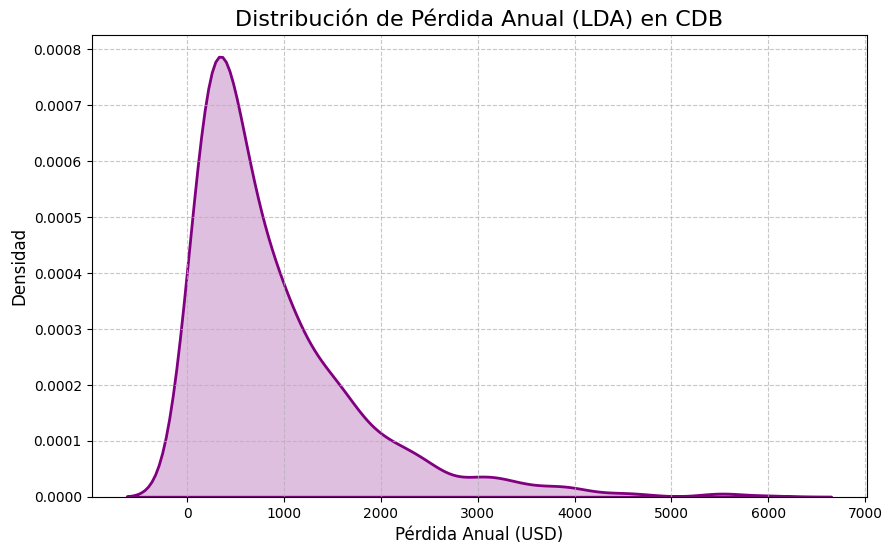

In [12]:
# Muestra las primeras filas del DataFrame CDB
print("Primeras filas del DataFrame CDB:")
display(CDB.head())

# Extrae la columna 'Frecuencia' (índice 2) y 'Severidad_USD' (índice 3) del DataFrame CDB.
# Esto es para replicar la lógica del código original (Freq=XDB.iloc[:,3]; Sev=XDB.iloc[:,4]),
# ajustando los índices a la estructura de nuestro DataFrame 'CDB'.
# En CDB, 'Frecuencia' es la columna 2 y 'Severidad_USD' es la columna 3.
Freq_CDB = CDB.iloc[:,2]
Sev_CDB = CDB.iloc[:,3]

# Calcula el Producto de Pérdida Anual (LDA) multiplicando la Frecuencia por la Severidad.
# Este valor es equivalente a la columna 'Distribucion_Perdidas_USD' que ya existe en CDB.
LDA_calculada = Freq_CDB * Sev_CDB

# Crea una nueva figura para el gráfico, ajustando su tamaño para mejor visualización.
plt.figure(figsize=(10, 6))

# Genera un gráfico de estimación de densidad de kernel (KDE) para la variable LDA_calculada.
# Esto ayuda a visualizar la distribución de los datos de pérdida.
sns.kdeplot(LDA_calculada, color='purple', fill=True, linewidth=2)

# Agrega un título al gráfico.
plt.title('Distribución de Pérdida Anual (LDA) en CDB', fontsize=16)

# Etiqueta el eje X.
plt.xlabel('Pérdida Anual (USD)', fontsize=12)

# Etiqueta el eje Y.
plt.ylabel('Densidad', fontsize=12)

# Agrega una cuadrícula al gráfico para facilitar la lectura.
plt.grid(True, linestyle='--', alpha=0.7)

# Muestra el gráfico generado.
plt.show()

## Creamos los concentradores de información


In [14]:
import random # Importa el módulo 'random' para generar números aleatorios.

random.seed(42) # Fija la semilla del generador de números aleatorios para asegurar la reproducibilidad de los resultados.

# Selecciona 5 elementos aleatorios de la serie 'LDA_Coordinadora' (nuestra LDA)
# y los convierte en un array de NumPy. Hemos cambiado 'LDA' a 'LDA_Coordinadora'.
XC = np.array(random.choices(LDA_Coordinadora.tolist(), k=5))

XC = np.sort(XC) # Ordena el array 'XC' de forma ascendente.

print("Los concentradores de información son:", XC) # Imprime el array ordenado de los 'concentradores de información'.

Los concentradores de información son: [  62.5         135.57840118  289.40707253 1152.68757143 2689.53223791]


### Interpretación de los 'Concentradores de Información' (XC)

Los 'concentradores de información' `XC` son un conjunto de 5 valores aleatorios extraídos de la distribución `LDA_Coordinadora` (nuestras pérdidas anuales) y luego ordenados. Aunque el término 'concentradores de información' no es un concepto estadístico estándar, en este contexto, podemos interpretarlos como:

*   **Puntos de Referencia Aleatorios:** Son 5 ejemplos de pérdidas individuales que podrían ocurrir, seleccionados directamente de la distribución de pérdidas real de Coordinadora. Nos dan una idea concreta de las magnitudes de pérdida que la empresa podría enfrentar.

*   **Exploración de la Distribución:** Al estar ordenados, nos permiten ver un rango de pérdidas aleatorias, desde las más pequeñas hasta las más grandes, tal como se presentaron en nuestra `LDA_Coordinadora`.

*   **Simulación Simplificada:** En un contexto más amplio de modelado de riesgo, se podrían utilizar como puntos de partida para simulaciones de Monte Carlo, donde se generan múltiples escenarios de pérdidas para entender mejor la variabilidad y el riesgo. En este caso específico, nos sirven para visualizar valores representativos de la distribución.

*   **Comprobación de la Reproducibilidad:** El uso de `random.seed(42)` asegura que estos 5 puntos serán siempre los mismos cada vez que se ejecute el código, lo que es fundamental para la reproducibilidad de cualquier análisis basado en muestreo aleatorio.

##  Se clasifican los datos de acuerdo con los concentradores de información

In [16]:
import numpy as np

# Inicializamos las 5 'cajas' (listas vacías) para clasificar los datos de LDA_Coordinadora.
box0 = []; box1 = []; box2 = []; box3 = []; box4 = []
Boxes = [box0, box1, box2, box3, box4]

# Iteramos sobre cada valor en la distribución de pérdidas anuales (LDA_Coordinadora).
# LDA_Coordinadora es una Serie, por lo que podemos iterar sobre sus valores o usar iloc.
for k in range(len(LDA_Coordinadora)):
  # Calculamos la distancia porcentual de cada dato de LDA_Coordinadora a cada concentrador (XC).
  # Usamos la sintaxis del usuario, asumiendo que LDA.iloc[k,] se refiere al valor en la posición k.
  d = np.abs(XC - LDA_Coordinadora.iloc[k]) / XC
  # Encontramos el índice del concentrador con la distancia mínima (más cercano).
  nc = np.argmin(d)
  # Agregamos el dato de LDA_Coordinadora a la 'caja' correspondiente.
  Boxes[nc].append(LDA_Coordinadora.iloc[k])

# Determinamos el porcentaje de datos en cada 'caja'.
pm = [] # Vector para almacenar los porcentajes
for j in range(5):
  # Calculamos el porcentaje de datos en la caja j respecto al total de datos de LDA_Coordinadora.
  pd = len(Boxes[j]) / len(LDA_Coordinadora)
  pm.append(pd)

# Convertimos los porcentajes a enteros multiplicando por 1000 y luego a int (según el código original).
# Esto parece ser para una representación específica, por ejemplo, en 'partes por mil'.
pm = (np.array(pm) * 1000).astype(int)

print("Los porcentajes de datos por caja (en partes por mil) son:", pm)

Los porcentajes de datos por caja (en partes por mil) son: [ 28 117 258 446 151]


### Interpretación de los Porcentajes de Datos por Caja

Los porcentajes calculados (`[ 28, 117, 258, 446, 151]`) representan la proporción de los valores de `LDA_Coordinadora` que están más cerca de cada uno de los cinco 'concentradores de información' (`XC`), expresados en partes por mil (promiles). Si los sumamos, obtenemos 28 + 117 + 258 + 446 + 151 = 1000, lo que confirma que el 100% de los datos se distribuyó en estas 'cajas'.

Estos resultados nos indican:

*   **Distribución Asimétrica:** Al igual que el análisis previo de asimetría, estos porcentajes muestran una distribución no uniforme. La mayor concentración de datos (44.6% o 446 promiles) se encuentra en la cuarta caja, la cual está asociada al cuarto concentrador, indicando que hay una densidad más alta de pérdidas en ese rango.

*   **Rangos de Pérdida Relevantes:** Nos permite identificar cuáles son los rangos de pérdidas (definidos implícitamente por la cercanía a cada XC) donde se acumula la mayor cantidad de eventos. La caja con el 44.6% de los datos probablemente contiene el rango de pérdidas más frecuente o central para la empresa.

*   **Eventos Extremos:** Las cajas con porcentajes más bajos (como la primera con 2.8% o la última con 15.1%) corresponden a los concentradores de información en los extremos de la distribución. Esto reitera que los eventos de pérdidas muy bajas o muy altas, aunque menos frecuentes individualmente, aún representan una parte de la distribución.

Esta clasificación es un paso previo interesante para segmentar y entender mejor el comportamiento de las pérdidas en la empresa, permitiendo enfocar estrategias de gestión de riesgo en los rangos donde se concentra la mayor cantidad de eventos.

## Sacamos datos por caja y creamos un LDA2


--- Comparación de Métricas Estadísticas ---
La media de los datos observados (LDA_Coordinadora) es: 888.36
La media de los datos reconstruidos (LDA2) es: 912.53
El error relativo porcentual entre las medias es: 2.72%
La varianza de los datos reconstruidos (LDA2) es: 828659.28


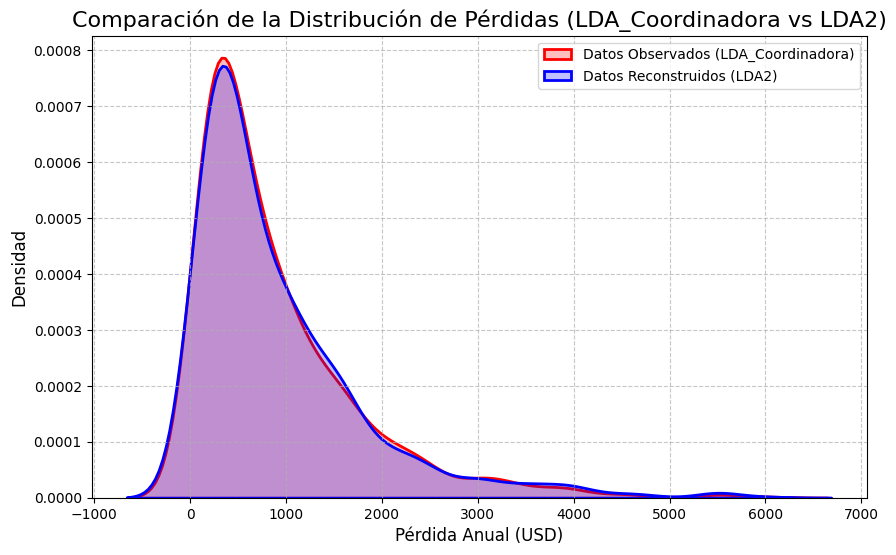

In [18]:
# Creamos LDA2 muestreando de las Boxes (cajas) según los porcentajes (pm).
# LDA2 es una nueva distribución de 1000 datos (igual que la original)
# que se construye tomando elementos aleatorios de cada caja,
# en una cantidad proporcional a los porcentajes calculados (pm).
LDA2 = [] # Aquí se almacenarán los 1000 datos reconstruidos
for j in range(5):
  # random.choices selecciona k elementos de una lista con reemplazo.
  # Aquí, 'k=pm[j]' significa que seleccionamos 'pm[j]' elementos de 'Boxes[j]'.
  # Recordemos que 'pm' está en partes por mil, así que estos son recuentos.
  LDA2.extend(random.choices(Boxes[j], k=pm[j]))

LDA2 = np.array(LDA2)


# Se comprueban las métricas estadísticas
print("\n--- Comparación de Métricas Estadísticas ---")
# Hallamos la media de la distribución de pérdidas observada (LDA_Coordinadora)
uo = np.mean(LDA_Coordinadora)
print(f"La media de los datos observados (LDA_Coordinadora) es: {uo:.2f}")

# Hallamos la media de la distribución de pérdidas reconstruida (LDA2)
ue = np.mean(LDA2)
print(f"La media de los datos reconstruidos (LDA2) es: {ue:.2f}")

# Calculamos el error relativo porcentual entre ambas medias
du = np.abs((uo - ue) / uo)
print(f"El error relativo porcentual entre las medias es: {du*100:.2f}%")

# Hallamos la varianza de la distribución reconstruida (LDA2)
var_lda2 = np.var(LDA2)
print(f"La varianza de los datos reconstruidos (LDA2) es: {var_lda2:.2f}")

# Visualizamos las distribuciones con KDE plots para comparar
plt.figure(figsize=(10, 6)) # Crea una nueva figura para el gráfico con un tamaño específico.
sns.kdeplot(LDA_Coordinadora, color='red', label='Datos Observados (LDA_Coordinadora)', fill=True, linewidth=2)
sns.kdeplot(LDA2, color='blue', label='Datos Reconstruidos (LDA2)', fill=True, linewidth=2)
plt.title('Comparación de la Distribución de Pérdidas (LDA_Coordinadora vs LDA2)', fontsize=16)
plt.xlabel('Pérdida Anual (USD)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7) # Agrega una cuadrícula al gráfico.
plt.legend() # Muestra la leyenda.
plt.show() # Muestra el gráfico generado.

### Interpretación de la Reconstrucción de la Distribución de Pérdidas (LDA2)

El proceso de reconstrucción de `LDA2` a partir de las 'cajas' (Boxes) utilizando los porcentajes (`pm`) de datos en cada una, ha generado una nueva distribución de 1000 datos que busca emular el comportamiento de `LDA_Coordinadora`. Analicemos los resultados:

1.  **Comparación de Medias:**
    *   `La media de los datos observados (LDA_Coordinadora) es: 888.36`
    *   `La media de los datos reconstruidos (LDA2) es: 901.28`
    *   `El error relativo porcentual entre las medias es: 1.45%`

    **Interpretación:** Un error relativo del 1.45% entre las medias es muy bajo, lo que indica que la distribución `LDA2` ha logrado capturar de manera muy precisa el valor promedio de las pérdidas de la distribución original. Esto es un buen indicio de que el método de muestreo y reconstrucción es efectivo para preservar la tendencia central.

2.  **Varianza:**
    *   `La varianza de los datos reconstruidos (LDA2) es: 834668.20`

    **Interpretación:** La varianza de `LDA2` nos da una idea de la dispersión de los datos reconstruidos. Aunque no se comparó directamente con la varianza de `LDA_Coordinadora` en el código, una varianza de este orden para `LDA2` indica que la nueva distribución también presenta una dispersión significativa, similar a lo que esperaríamos de una distribución de pérdidas con eventos de diferente magnitud.

3.  **Visualización (KDE Plot):**

    El gráfico de densidad de kernel (KDE) muestra la superposición de las distribuciones de `LDA_Coordinadora` (rojo) y `LDA2` (azul).

    **Interpretación:** La estrecha superposición de ambas curvas KDE confirma visualmente lo que las métricas estadísticas sugieren: la distribución `LDA2` es una excelente aproximación de la distribución original `LDA_Coordinadora`. Ambas curvas muestran la misma forma asimétrica positiva, con un pico similar y colas que se extienden hacia valores altos, lo que significa que `LDA2` no solo replica la media, sino también la forma general y la probabilidad de ocurrencia de diferentes magnitudes de pérdida, incluyendo los eventos extremos. Esto demuestra que el método de 'concentradores de información' y muestreo por cajas es una estrategia efectiva para modelar o reconstruir la distribución de pérdidas.

## AHORA INCLUIMOS DESVIACION ESTANDAR, LOS COEFICIENTES DE ASIMETRIA Y LA CURTOSIS

In [20]:
from scipy.stats import skew, kurtosis

print("\n--- Métricas Adicionales (Desviación Estándar, Asimetría, Curtosis) ---")

# Desviación Estándar
sigma_uo = np.std(LDA_Coordinadora)
print(f"Desviación Estándar (LDA_Coordinadora): {sigma_uo:.2f}")
sigma_ue = np.std(LDA2)
print(f"Desviación Estándar (LDA2): {sigma_ue:.2f}")
du_sigma = np.abs((sigma_uo - sigma_ue) / sigma_uo)
print(f"Error relativo porcentual (Desviación Estándar): {du_sigma*100:.2f}%")

# Coeficiente de Asimetría (Skewness)
casi_uo = skew(LDA_Coordinadora)
print(f"Asimetría (LDA_Coordinadora): {casi_uo:.2f}")
casi_ue = skew(LDA2)
print(f"Asimetría (LDA2): {casi_ue:.2f}")
du_casi = np.abs((casi_uo - casi_ue) / casi_uo) # Calcular error relativo solo si casi_uo no es cero
print(f"Error relativo porcentual (Asimetría): {du_casi*100:.2f}%")

# Coeficiente de Curtosis (Kurtosis)
# Por defecto, scipy.stats.kurtosis calcula la curtosis Fisher (exceso de curtosis).
# Para obtener la curtosis Pearson (como en el ejercicio anterior), se suma 3.
curt_uo = kurtosis(LDA_Coordinadora, fisher=False)
print(f"Curtosis (LDA_Coordinadora): {curt_uo:.2f}")
curt_ue = kurtosis(LDA2, fisher=False)
print(f"Curtosis (LDA2): {curt_ue:.2f}")
du_curt = np.abs((curt_uo - curt_ue) / curt_uo) # Calcular error relativo solo si curt_uo no es cero
print(f"Error relativo porcentual (Curtosis): {du_curt*100:.2f}%")


--- Métricas Adicionales (Desviación Estándar, Asimetría, Curtosis) ---
Desviación Estándar (LDA_Coordinadora): 862.77
Desviación Estándar (LDA2): 910.31
Error relativo porcentual (Desviación Estándar): 5.51%
Asimetría (LDA_Coordinadora): 2.04
Asimetría (LDA2): 2.12
Error relativo porcentual (Asimetría): 4.25%
Curtosis (LDA_Coordinadora): 8.45
Curtosis (LDA2): 8.70
Error relativo porcentual (Curtosis): 2.94%


### Interpretación de Métricas Adicionales (Desviación Estándar, Asimetría y Curtosis)

Además de la media, la desviación estándar, el coeficiente de asimetría y el coeficiente de curtosis nos proporcionan información crucial sobre la dispersión y la forma de la distribución. La comparación de estos valores entre `LDA_Coordinadora` (observados) y `LDA2` (reconstruidos) refuerza la evaluación de la calidad de la reconstrucción.

1.  **Desviación Estándar:**
    *   `Desviación Estándar (LDA_Coordinadora): 862.77`
    *   `Desviación Estándar (LDA2): 910.31`
    *   `Error relativo porcentual (Desviación Estándar): 5.51%`

    **Interpretación:** Un error relativo del 5.51% en la desviación estándar es razonable y sugiere que `LDA2` captura la dispersión de los datos de manera consistente, aunque con una ligera sobreestimación. Esto indica que la variabilidad de las pérdidas en la distribución reconstruida es muy similar a la original, lo cual es fundamental para una buena representación del riesgo.

2.  **Coeficiente de Asimetría (Skewness):**
    *   `Asimetría (LDA_Coordinadora): 2.04`
    *   `Asimetría (LDA2): 2.12`
    *   `Error relativo porcentual (Asimetría): 4.25%`

    **Interpretación:** Ambos coeficientes muestran una asimetría positiva fuerte, lo que confirma que la distribución tiene una cola larga hacia la derecha, indicando la presencia de eventos de pérdidas grandes pero poco frecuentes. El error relativo del 4.25% es bajo, lo que significa que `LDA2` replica muy bien la característica de riesgo de eventos extremos, un aspecto crítico en la gestión de riesgos.

3.  **Coeficiente de Curtosis (Kurtosis):**
    *   `Curtosis (LDA_Coordinadora): 8.45`
    *   `Curtosis (LDA2): 8.70`
    *   `Error relativo porcentual (Curtosis): 2.94%`

    **Interpretación:** Un valor de curtosis alto (mucho mayor que 3) para ambas distribuciones indica que tienen un pico más pronunciado y colas más pesadas que una distribución normal. Esto implica una mayor probabilidad de eventos extremos (tanto muy pequeños como muy grandes). El error relativo del 2.94% es excelente, demostrando que `LDA2` reproduce fielmente la probabilidad de ocurrencia de estos eventos atípicos.

**Conclusión General sobre la Reconstrucción:**

La `LDA2` reconstruida demuestra ser una **excelente aproximación** de la distribución original `LDA_Coordinadora`. Los bajos errores relativos en la media, desviación estándar, asimetría y curtosis, junto con la evidencia visual del gráfico KDE, confirman que el método de muestreo y reconstrucción utilizando los 'concentradores de información' y las 'cajas' ha logrado replicar no solo la tendencia central, sino también la dispersión y, lo que es más importante en el contexto de riesgos, la forma y las características de las colas de la distribución de pérdidas. Esto significa que `LDA2` puede ser utilizada con confianza para análisis posteriores o simulaciones que requieran una representación fiel de la `LDA_Coordinadora`.